In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive/Lung_disease"


lung_dataset  outputs


In [ ]:
!ls "/content/drive/MyDrive/Lung_disease/lung_dataset"


test  train


In [ ]:
!ls "/content/drive/MyDrive/lung_disease/Lung_dataset/train"
!ls "/content/drive/MyDrive/lung_disease/Lung_dataset/train/NORMAL" | head


ls: cannot access '/content/drive/MyDrive/lung_disease/Lung_dataset/train': No such file or directory
ls: cannot access '/content/drive/MyDrive/lung_disease/Lung_dataset/train/NORMAL': No such file or directory


In [ ]:
!ls "/content/drive/MyDrive/Lung_disease/lung_dataset/train"
!ls "/content/drive/MyDrive/Lung_disease/lung_dataset/train/NORMAL" | head


NORMAL	PNEUMONIA  TUBERCULOSIS
IM-0115-0001.jpeg
IM-0117-0001.jpeg
IM-0119-0001.jpeg
IM-0122-0001.jpeg
IM-0125-0001.jpeg
IM-0127-0001.jpeg
IM-0128-0001.jpeg
IM-0129-0001.jpeg
IM-0131-0001.jpeg
IM-0133-0001.jpeg


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


In [ ]:
train_dir = "/content/drive/MyDrive/Lung_disease/lung_dataset/train"
test_dir  = "/content/drive/MyDrive/Lung_disease/lung_dataset/test"

train_data = datasets.ImageFolder(train_dir, transform=transform)
test_data  = datasets.ImageFolder(test_dir,  transform=transform)


In [ ]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

classes = train_data.classes
print("Detected classes:", classes)


Detected classes: ['NORMAL', 'PNEUMONIA', 'TUBERCULOSIS']


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models


In [ ]:
model = models.resnet18(pretrained=True)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 205MB/s]


In [ ]:
for param in model.parameters():
    param.requires_grad = False


In [ ]:
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 3)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)


In [ ]:
print(model)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [1]:
epochs = 8
train_loss_history = []
train_acc_history = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_loss_history.append(epoch_loss)
    train_acc_history.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{epochs}] → Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

print("✅ Training Complete!")


NameError: name 'model' is not defined

In [2]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=classes))


NameError: name 'model' is not defined

In [ ]:
from sklearn.metrics import classification_report

print("📊 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=classes))


📊 Classification Report:

              precision    recall  f1-score   support

      NORMAL       0.92      0.60      0.73       234
   PNEUMONIA       0.81      0.98      0.89       390
TUBERCULOSIS       0.92      0.93      0.92       152

    accuracy                           0.86       776
   macro avg       0.89      0.84      0.85       776
weighted avg       0.87      0.86      0.85       776



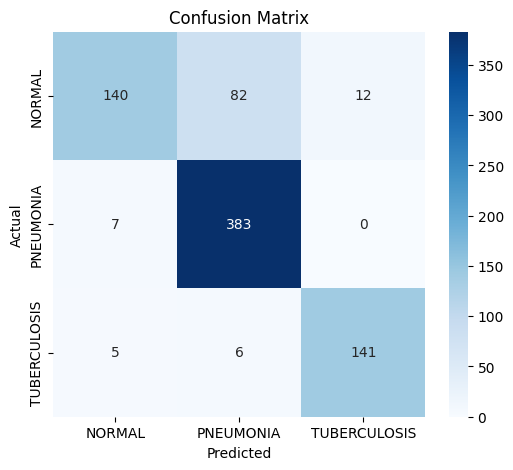

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


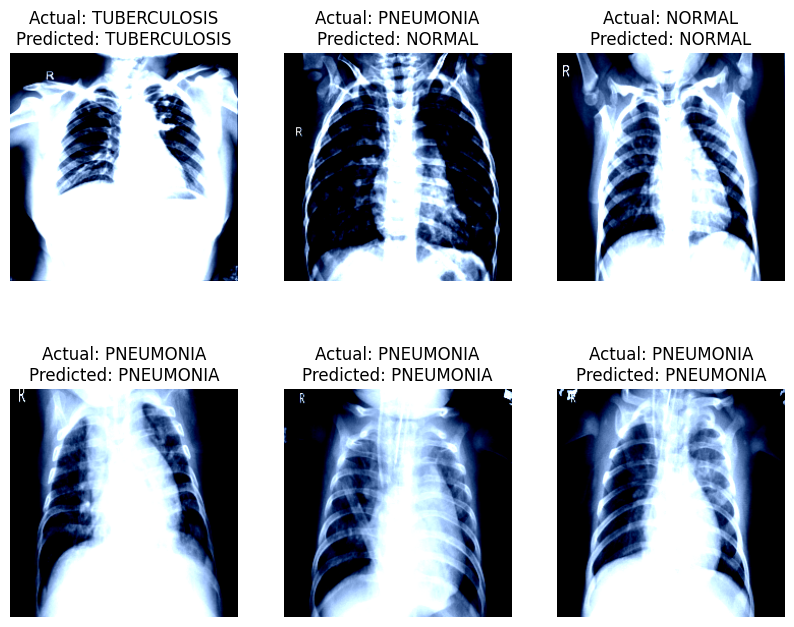

In [ ]:
import random

model.eval()
plt.figure(figsize=(10,8))
for i in range(6):
    idx = random.randint(0, len(test_data)-1)
    img, label = test_data[idx]
    with torch.no_grad():
        output = model(img.unsqueeze(0).to(device))
        _, pred = torch.max(output, 1)
    plt.subplot(2,3,i+1)
    plt.imshow(np.transpose(img.numpy(), (1,2,0)))
    plt.title(f"Actual: {classes[label]}\nPredicted: {classes[pred.item()]}")
    plt.axis('off')
plt.show()


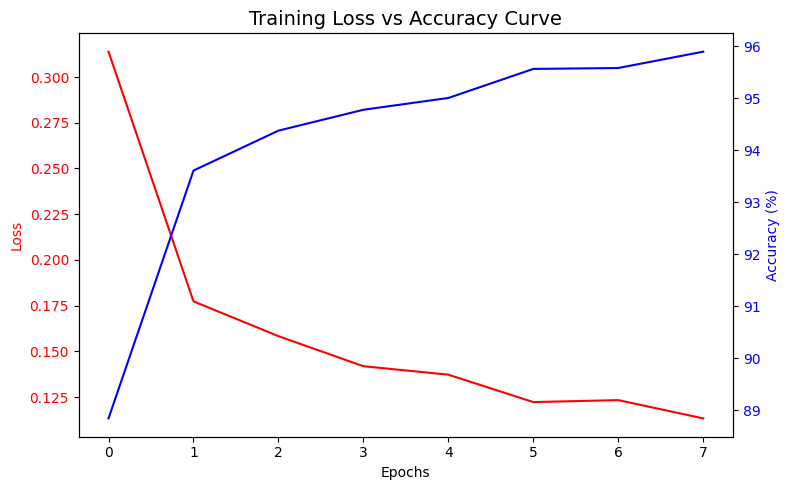

In [ ]:
fig, ax1 = plt.subplots(figsize=(8,5))

ax1.plot(train_loss_history, color='red', label='Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss', color='red')
ax1.tick_params(axis='y', labelcolor='red')

ax2 = ax1.twinx()
ax2.plot(train_acc_history, color='blue', label='Accuracy')
ax2.set_ylabel('Accuracy (%)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title("Training Loss vs Accuracy Curve", fontsize=14)
fig.tight_layout()
plt.show()


In [3]:
import os

save_dir = "/content/drive/MyDrive/Lung_disease/outputs"
os.makedirs(save_dir, exist_ok=True)


In [ ]:
model_path = "/content/drive/MyDrive/Lung_disease/outputs/infectious_model.pth"
torch.save(model.state_dict(), model_path)
print(f"✅ Model saved successfully at:\n{model_path}")


✅ Model saved successfully at:
/content/drive/MyDrive/Lung_disease/outputs/infectious_model.pth
